# Machine Learning Safety — Exercise 8
## Adversarial Machine Learning

This notebook implements and analyzes adversarial attacks on the CARLA perception models using the Fast Gradient Sign Method (FGSM).

### Models
- Pedestrian classifier
- Vehicle classifier
- Traffic-light classifier

### Main topics
- Adversarial examples
- Attack formulation
- Adversarial training
- FGSM
- Adversarial robustness
- Recall degradation
- Safety analysis

In [1]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
import os

ML_SAFETY_PATH = "/content/drive/MyDrive/ML_Safety"

TRAIN_ZIP = os.path.join(ML_SAFETY_PATH, "train.zip")
VALIDATION_ZIP = os.path.join(ML_SAFETY_PATH, "validation.zip")
TEST_ZIP = os.path.join(ML_SAFETY_PATH, "test.zip")

PED_MODEL_PATH = os.path.join(
    ML_SAFETY_PATH, "pedestrian_model.pth"
)

VEH_MODEL_PATH = os.path.join(
    ML_SAFETY_PATH, "vehicle_model.pth"
)

TL_MODEL_PATH = os.path.join(
    ML_SAFETY_PATH, "traffic_light_model.pth"
)

print("ML Safety directory:")
print(ML_SAFETY_PATH)

print("\nChecking required files...")

required_files = [
    TRAIN_ZIP,
    VALIDATION_ZIP,
    TEST_ZIP,
    PED_MODEL_PATH,
    VEH_MODEL_PATH,
    TL_MODEL_PATH
]

for path in required_files:
    print("✓" if os.path.exists(path) else "✗", os.path.basename(path))

ML Safety directory:
/content/drive/MyDrive/ML_Safety

Checking required files...
✓ train.zip
✓ validation.zip
✓ test.zip
✓ pedestrian_model.pth
✓ vehicle_model.pth
✓ traffic_light_model.pth


In [3]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [4]:
TEST_EXTRACT_PATH = "/content/test"

if not os.path.exists(TEST_EXTRACT_PATH):
    os.makedirs(TEST_EXTRACT_PATH)

    with zipfile.ZipFile(TEST_ZIP, "r") as zip_ref:
        zip_ref.extractall(TEST_EXTRACT_PATH)

    print("Test dataset extracted successfully.")
else:
    print("Test dataset already exists.")

Test dataset extracted successfully.


In [5]:
labels_path = os.path.join(
    TEST_EXTRACT_PATH,
    "test",
    "labels.csv"
)

print("Labels path:", labels_path)
print("Exists:", os.path.exists(labels_path))

Labels path: /content/test/test/labels.csv
Exists: True


In [6]:
labels_df = pd.read_csv(labels_path)

print("Labels shape:", labels_df.shape)
print("\nColumns:")
print(labels_df.columns.tolist())

display(labels_df.head())

Labels shape: (3600, 7)

Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


Number of test images: 3600
First image: /content/test/test/rgb-front/000000.jpg
Image size: (500, 500)
Image mode: RGB


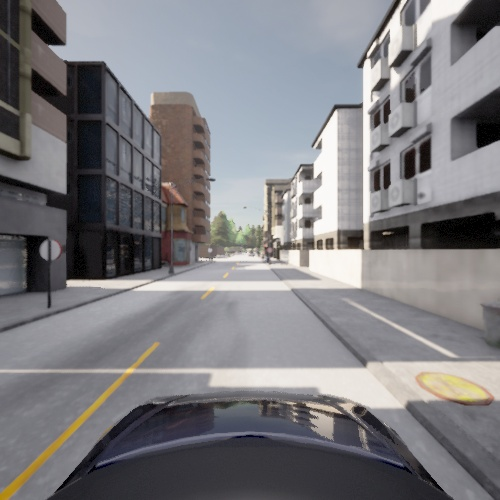

In [7]:
import glob

image_dir = os.path.join(
    TEST_EXTRACT_PATH,
    "test",
    "rgb-front"
)

image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))

print("Number of test images:", len(image_files))
print("First image:", image_files[0])

img = Image.open(image_files[0])

print("Image size:", img.size)
print("Image mode:", img.mode)

display(img)

## 8.4 — Generating Adversarial Examples

The CARLA RGB-front images have a resolution of 500×500 pixels.
The trained perception models expect images resized to 240×240 pixels.

The preprocessing converts the RGB images to tensors and scales pixel
values to the range [0, 1].

In [9]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor()
])

print("Image preprocessing defined successfully.")

Image preprocessing defined successfully.


In [10]:
class PerceptionClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [11]:
model_test = PerceptionClassifier().to(device)

dummy_input = torch.randn(1, 3, 240, 240).to(device)

with torch.no_grad():
    dummy_output = model_test(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape : torch.Size([1, 3, 240, 240])
Output shape: torch.Size([1, 1])


In [12]:
pedestrian_model = PerceptionClassifier().to(device)
vehicle_model = PerceptionClassifier().to(device)
traffic_light_model = PerceptionClassifier().to(device)

pedestrian_model.load_state_dict(
    torch.load(PED_MODEL_PATH, map_location=device)
)

vehicle_model.load_state_dict(
    torch.load(VEH_MODEL_PATH, map_location=device)
)

traffic_light_model.load_state_dict(
    torch.load(TL_MODEL_PATH, map_location=device)
)

pedestrian_model.eval()
vehicle_model.eval()
traffic_light_model.eval()

print("All three models loaded successfully.")
print("Device:", device)

All three models loaded successfully.
Device: cuda


# Exercise 8 — Adversarial Machine Learning

This exercise studies adversarial attacks against the CARLA perception models.

The goal is to understand how small, intentionally designed perturbations can cause a machine learning model to make incorrect predictions, and how this affects the safety of an autonomous driving system.

### Tasks

- Understand adversarial examples and attack formulations.
- Generate adversarial examples using the Fast Gradient Sign Method (FGSM).
- Evaluate the robustness of the pedestrian, vehicle, and traffic-light classifiers.
- Measure the recall drop caused by adversarial perturbations.
- Extend the System-Theoretic Process Analysis (STPA) safety analysis to adversarial attacks.

## Exercise 8.1 — What Are Adversarial Examples?

An adversarial example is an input that has been intentionally modified with a small perturbation so that a machine learning model produces an incorrect prediction.

The perturbation is usually designed to be small enough that the modified input still appears normal or almost unchanged to a human observer.

Adversarial examples differ from Out-of-Distribution (OOD) examples:

- **Adversarial examples** are intentionally constructed to fool a trained model.
- **OOD examples** come from a distribution that differs from the training distribution and are not necessarily intentionally designed to cause an error.

Therefore, an adversarial example can still look very similar to a normal input while causing a significant change in the model's prediction.

## Exercise 8.2 — Attack Formulation

A basic gradient-based adversarial attack can be written as:

$$
x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x L(y, f(x)))
$$

where:

- $x$ is the original input.
- $x_{adv}$ is the adversarial input.
- $\epsilon$ controls the perturbation magnitude.
- $L$ is the loss function.
- $f(x)$ is the model prediction.
- $\nabla_x L$ is the gradient of the loss with respect to the input.
- $\text{sign}(\cdot)$ gives the direction of the gradient.

### Targeted vs. Untargeted Attacks

An **untargeted attack** tries to make the model produce any incorrect prediction.

A **targeted attack** tries to make the model predict a specific incorrect class.

For a targeted attack, the optimization direction is reversed so that the loss for the desired target class is minimized.

### Perturbation Budget

The basic update does not automatically guarantee a perturbation constraint such as:

$$
\|x_{adv} - x\|_\infty \leq \epsilon
$$

The perturbation can be constrained by clipping the adversarial input so that every pixel remains within the allowed $\epsilon$ distance from the original input.

## Exercise 8.3 — Defenses

One possible defense against adversarial attacks is **adversarial training**.

During adversarial training, adversarial examples are generated during training and included in the training data. The model is therefore trained not only on clean examples but also on deliberately perturbed examples.

This can improve robustness against adversarial attacks.

However, adversarial training introduces a trade-off:

- It can improve robustness against attacks.
- It increases training computational cost.
- It may reduce performance on clean inputs.
- Robustness against one type of attack does not necessarily guarantee robustness against all attacks.

## Practical: Attacking the CARLA Model

### Exercise 8.4 — Generating Adversarial Examples

We use the Fast Gradient Sign Method (FGSM) to generate adversarial examples for the three perception classifiers:

1. Pedestrian classifier
2. Vehicle classifier
3. Traffic-light classifier

The attack is evaluated for:

$$
\epsilon \in \{0.01,\ 0.05,\ 0.1\}
$$

In [13]:
import os
import glob
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


In [14]:
class CARLATestDataset(Dataset):
    def __init__(self, image_dir, labels_csv, transform=None):
        self.image_dir = image_dir
        self.labels = pd.read_csv(labels_csv)
        self.transform = transform

        self.image_files = sorted(
            glob.glob(os.path.join(image_dir, "*.jpg"))
        )

        assert len(self.image_files) == len(self.labels), (
            f"Number of images ({len(self.image_files)}) "
            f"does not match labels ({len(self.labels)})"
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = Image.open(self.image_files[idx]).convert("RGB")
        row = self.labels.iloc[idx]

        if self.transform:
            image = self.transform(image)

        pedestrian = torch.tensor(
            float(row["has_pedestrian"]),
            dtype=torch.float32
        )

        vehicle = torch.tensor(
            float(row["has_vehicle"]),
            dtype=torch.float32
        )

        traffic_light = torch.tensor(
            float(row["has_traffic_light"]),
            dtype=torch.float32
        )

        return image, pedestrian, vehicle, traffic_light

In [16]:
class CarlaDataset(torch.utils.data.Dataset):

    def __init__(self, image_dir, labels_csv, transform=None):
        self.image_dir = image_dir
        self.labels = pd.read_csv(labels_csv)
        self.transform = transform

        self.image_files = sorted(
            glob.glob(os.path.join(image_dir, "*.jpg"))
        )

        assert len(self.image_files) == len(self.labels), (
            f"Number of images ({len(self.image_files)}) "
            f"does not match labels ({len(self.labels)})"
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image = Image.open(self.image_files[idx]).convert("RGB")
        row = self.labels.iloc[idx]

        if self.transform:
            image = self.transform(image)

        pedestrian = torch.tensor(
            float(row["has_pedestrian"]),
            dtype=torch.float32
        )

        vehicle = torch.tensor(
            float(row["has_vehicle"]),
            dtype=torch.float32
        )

        traffic_light = torch.tensor(
            float(row["has_traffic_light"]),
            dtype=torch.float32
        )

        return image, pedestrian, vehicle, traffic_light

In [17]:
import os
import glob
import torch
import pandas as pd
from PIL import Image

In [19]:
# Test dataset paths

TEST_IMAGE_DIR = "/content/test/test/rgb-front"
TEST_LABELS_PATH = "/content/test/test/labels.csv"

print("Test image directory:", TEST_IMAGE_DIR)
print("Test labels file:", TEST_LABELS_PATH)

Test image directory: /content/test/test/rgb-front
Test labels file: /content/test/test/labels.csv


In [20]:
test_dataset = CarlaDataset(
    image_dir=TEST_IMAGE_DIR,
    labels_csv=TEST_LABELS_PATH,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test dataset size:", len(test_dataset))
print("Number of batches:", len(test_loader))

Test dataset size: 3600
Number of batches: 113


In [21]:
# Check the output of each model

images, pedestrian_labels, vehicle_labels, traffic_light_labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    ped_output = pedestrian_model(images[:4])
    veh_output = vehicle_model(images[:4])
    tl_output = traffic_light_model(images[:4])

print("Pedestrian output:")
print(ped_output)

print("\nVehicle output:")
print(veh_output)

print("\nTraffic Light output:")
print(tl_output)

Pedestrian output:
tensor([[-6.4227],
        [-8.4982],
        [-8.4592],
        [-8.4855]], device='cuda:0')

Vehicle output:
tensor([[0.8052],
        [0.7977],
        [1.4330],
        [1.4482]], device='cuda:0')

Traffic Light output:
tensor([[-6.7416],
        [ 4.4107],
        [ 4.3738],
        [ 4.4131]], device='cuda:0')


In [22]:
def fgsm_attack(model, images, labels, epsilon):
    """
    Fast Gradient Sign Method (FGSM)

    x_adv = x + epsilon * sign(gradient of loss w.r.t. x)
    """

    # Make a copy and enable gradients
    images = images.clone().detach().to(device)
    images.requires_grad = True

    labels = labels.float().to(device).view(-1, 1)

    # Forward pass
    outputs = model(images)

    # Binary classification loss
    loss_fn = torch.nn.BCEWithLogitsLoss()
    loss = loss_fn(outputs, labels)

    # Clear old gradients
    model.zero_grad()

    # Compute gradient with respect to input
    loss.backward()

    # FGSM perturbation
    perturbation = epsilon * images.grad.sign()

    # Create adversarial image
    adversarial_images = images + perturbation

    return adversarial_images.detach(), perturbation.detach(), loss.item()

In [23]:
# Get one test batch
images, pedestrian_labels, vehicle_labels, traffic_light_labels = next(iter(test_loader))

# Test FGSM on the pedestrian model
epsilon = 0.01

adv_images, perturbation, loss = fgsm_attack(
    pedestrian_model,
    images,
    pedestrian_labels,
    epsilon
)

print("Original image shape:", images.shape)
print("Adversarial image shape:", adv_images.shape)
print("Perturbation shape:", perturbation.shape)
print("Loss:", loss)

print("Maximum perturbation:",
      perturbation.abs().max().item())

print("Mean perturbation:",
      perturbation.abs().mean().item())

Original image shape: torch.Size([32, 3, 240, 240])
Adversarial image shape: torch.Size([32, 3, 240, 240])
Perturbation shape: torch.Size([32, 3, 240, 240])
Loss: 0.12849396467208862
Maximum perturbation: 0.009999999776482582
Mean perturbation: 0.009890013374388218


In [24]:
# Exercise 8.4 — Generate FGSM adversarial examples

epsilons = [0.01, 0.05, 0.10]

models = {
    "Pedestrian": pedestrian_model,
    "Vehicle": vehicle_model,
    "Traffic Light": traffic_light_model
}

labels = {
    "Pedestrian": pedestrian_labels,
    "Vehicle": vehicle_labels,
    "Traffic Light": traffic_light_labels
}

adversarial_examples = {}

for model_name, model in models.items():

    adversarial_examples[model_name] = {}

    for epsilon in epsilons:

        adv_images, perturbation, loss = fgsm_attack(
            model,
            images,
            labels[model_name],
            epsilon
        )

        adversarial_examples[model_name][epsilon] = adv_images

        print(
            f"{model_name:15s} | "
            f"epsilon = {epsilon:.2f} | "
            f"loss = {loss:.4f} | "
            f"max perturbation = {perturbation.abs().max().item():.4f}"
        )

Pedestrian      | epsilon = 0.01 | loss = 0.1285 | max perturbation = 0.0100
Pedestrian      | epsilon = 0.05 | loss = 0.1285 | max perturbation = 0.0500
Pedestrian      | epsilon = 0.10 | loss = 0.1285 | max perturbation = 0.1000
Vehicle         | epsilon = 0.01 | loss = 0.6033 | max perturbation = 0.0100
Vehicle         | epsilon = 0.05 | loss = 0.6033 | max perturbation = 0.0500
Vehicle         | epsilon = 0.10 | loss = 0.6033 | max perturbation = 0.1000
Traffic Light   | epsilon = 0.01 | loss = 0.2539 | max perturbation = 0.0100
Traffic Light   | epsilon = 0.05 | loss = 0.2539 | max perturbation = 0.0500
Traffic Light   | epsilon = 0.10 | loss = 0.2539 | max perturbation = 0.1000


In [26]:
print("=" * 70)
print("FGSM PREDICTION COMPARISON")
print("=" * 70)

# Move images to the same device as the models
images = images.to(device)

def get_probability(model, x):
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        logits = model(x)
        return torch.sigmoid(logits).view(-1)

for model_name, model in models.items():

    model = model.to(device)

    clean_probs = get_probability(model, images)
    adv_probs = get_probability(model, adv_images)

    print(f"\n{model_name}")
    print("-" * 40)

    print("Clean probabilities:")
    print(clean_probs[:5])

    print("Adversarial probabilities:")
    print(adv_probs[:5])

FGSM PREDICTION COMPARISON

Pedestrian
----------------------------------------
Clean probabilities:
tensor([0.0016, 0.0002, 0.0002, 0.0002, 0.0002], device='cuda:0')
Adversarial probabilities:
tensor([5.5421e-05, 9.4157e-05, 1.0878e-04, 7.0929e-05, 7.5340e-05],
       device='cuda:0')

Vehicle
----------------------------------------
Clean probabilities:
tensor([0.6911, 0.6895, 0.8074, 0.8097, 0.8156], device='cuda:0')
Adversarial probabilities:
tensor([0.6033, 0.2739, 0.3738, 0.4440, 0.3684], device='cuda:0')

Traffic Light
----------------------------------------
Clean probabilities:
tensor([0.0012, 0.9880, 0.9876, 0.9880, 0.9881], device='cuda:0')
Adversarial probabilities:
tensor([1.0000e+00, 1.4980e-08, 2.2799e-08, 2.0154e-08, 2.2209e-08],
       device='cuda:0')


In [27]:
print("=" * 70)
print("FGSM PREDICTION CHANGES FOR ALL EPSILONS")
print("=" * 70)

images = images.to(device)

for model_name, model in models.items():

    model.eval()

    clean_probs = get_probability(model, images)
    clean_pred = (clean_probs >= 0.5).long()

    print(f"\n{model_name}")
    print("-" * 50)

    for epsilon in epsilons:

        adv_images = adversarial_examples[model_name][epsilon].to(device)

        adv_probs = get_probability(model, adv_images)
        adv_pred = (adv_probs >= 0.5).long()

        changed = (clean_pred != adv_pred).sum().item()

        print(
            f"epsilon = {epsilon:.2f} | "
            f"prediction changes = {changed}/{len(images)}"
        )

FGSM PREDICTION CHANGES FOR ALL EPSILONS

Pedestrian
--------------------------------------------------
epsilon = 0.01 | prediction changes = 0/32
epsilon = 0.05 | prediction changes = 14/32
epsilon = 0.10 | prediction changes = 22/32

Vehicle
--------------------------------------------------
epsilon = 0.01 | prediction changes = 15/32
epsilon = 0.05 | prediction changes = 21/32
epsilon = 0.10 | prediction changes = 21/32

Traffic Light
--------------------------------------------------
epsilon = 0.01 | prediction changes = 27/32
epsilon = 0.05 | prediction changes = 28/32
epsilon = 0.10 | prediction changes = 28/32


### Visual Comparison of Clean and Adversarial Images

The following visualization compares an original CARLA image with its FGSM adversarial versions for increasing perturbation magnitudes.

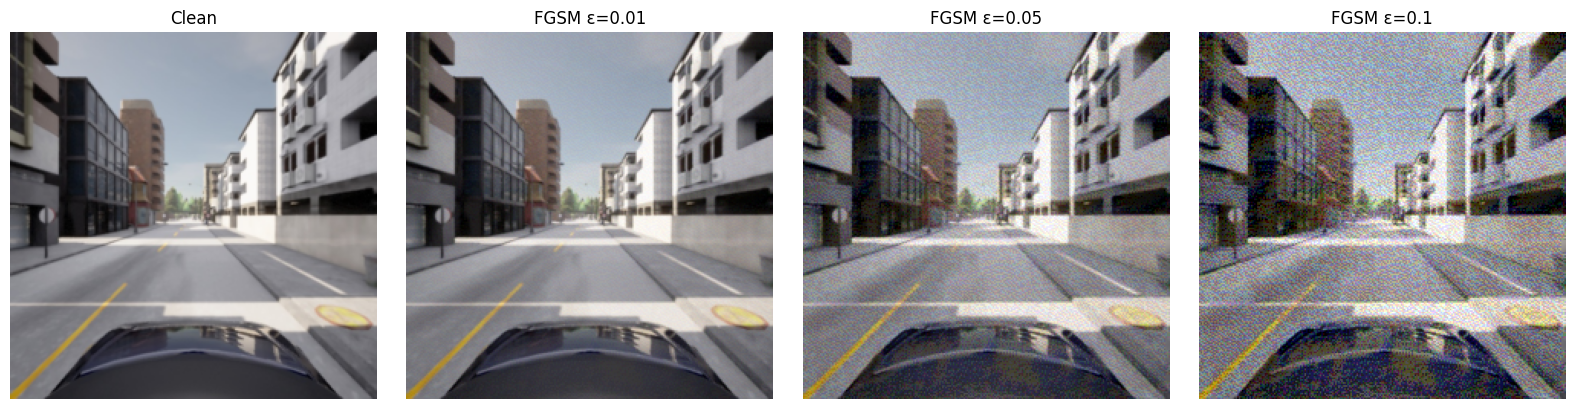

In [28]:
# Visualize one image for each epsilon

sample_index = 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Clean image
clean_image = images[sample_index].detach().cpu().permute(1, 2, 0).numpy()
clean_image = np.clip(clean_image, 0, 1)

axes[0].imshow(clean_image)
axes[0].set_title("Clean")
axes[0].axis("off")

# Pedestrian adversarial images
for i, epsilon in enumerate(epsilons, start=1):

    adv = adversarial_examples["Pedestrian"][epsilon][sample_index]
    adv = adv.detach().cpu().permute(1, 2, 0).numpy()
    adv = np.clip(adv, 0, 1)

    axes[i].imshow(adv)
    axes[i].set_title(f"FGSM ε={epsilon}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [29]:
print("=" * 70)
print("FGSM PREDICTION CHANGES FOR ALL EPSILONS")
print("=" * 70)

images = images.to(device)

for model_name, model in models.items():

    model.eval()

    clean_probs = get_probability(model, images)
    clean_pred = (clean_probs >= 0.5).long()

    print(f"\n{model_name}")
    print("-" * 50)

    for epsilon in epsilons:

        adv_images = adversarial_examples[model_name][epsilon].to(device)

        adv_probs = get_probability(model, adv_images)
        adv_pred = (adv_probs >= 0.5).long()

        changed = (clean_pred != adv_pred).sum().item()

        print(
            f"epsilon = {epsilon:.2f} | "
            f"prediction changes = {changed}/{len(images)}"
        )

FGSM PREDICTION CHANGES FOR ALL EPSILONS

Pedestrian
--------------------------------------------------
epsilon = 0.01 | prediction changes = 0/32
epsilon = 0.05 | prediction changes = 14/32
epsilon = 0.10 | prediction changes = 22/32

Vehicle
--------------------------------------------------
epsilon = 0.01 | prediction changes = 15/32
epsilon = 0.05 | prediction changes = 21/32
epsilon = 0.10 | prediction changes = 21/32

Traffic Light
--------------------------------------------------
epsilon = 0.01 | prediction changes = 27/32
epsilon = 0.05 | prediction changes = 28/32
epsilon = 0.10 | prediction changes = 28/32


## Exercise 8.5 — Measuring Robustness

We evaluate the pedestrian, vehicle, and traffic-light classifiers on clean test images and FGSM adversarial images.

For each perturbation magnitude ε ∈ {0.01, 0.05, 0.10}, we compute the recall and compare it with the clean recall.

The recall drop is calculated as:

Recall Drop = Clean Recall − Adversarial Recall

In [30]:
from sklearn.metrics import recall_score
import torch
import torch.nn.functional as F

print("=" * 75)
print("EXERCISE 8.5 — FULL ADVERSARIAL ROBUSTNESS EVALUATION")
print("=" * 75)

epsilons = [0.01, 0.05, 0.10]

# ------------------------------------------------------------
# FGSM attack
# ------------------------------------------------------------
def fgsm_attack(model, images, labels, epsilon):
    """
    Generate untargeted FGSM adversarial examples.
    """

    images = images.clone().detach().to(device)
    labels = labels.float().to(device)

    images.requires_grad = True

    model.eval()

    outputs = model(images).view(-1)

    loss = F.binary_cross_entropy_with_logits(outputs, labels)

    model.zero_grad()
    loss.backward()

    gradient = images.grad.sign()

    adv_images = images + epsilon * gradient

    # Keep pixel values in valid range
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()


# ------------------------------------------------------------
# Evaluate one model
# ------------------------------------------------------------
def evaluate_robustness(model, target_index, model_name):

    model.eval()

    clean_predictions = []
    clean_labels = []

    # Store batches so that we can generate adversarial examples
    # for each epsilon without loading the dataset again.
    batches = []

    print(f"\nEvaluating {model_name}...")

    # --------------------------------------------------------
    # First pass: collect clean predictions and labels
    # --------------------------------------------------------
    with torch.no_grad():

        for batch_images, ped_labels, veh_labels, tl_labels in test_loader:

            batch_images = batch_images.to(device)

            target_labels = [
                ped_labels,
                veh_labels,
                tl_labels
            ][target_index].float().to(device)

            outputs = model(batch_images).view(-1)
            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities >= 0.5).long()

            clean_predictions.extend(
                predictions.cpu().numpy()
            )

            clean_labels.extend(
                target_labels.long().cpu().numpy()
            )

            batches.append(
                (
                    batch_images.detach(),
                    target_labels.detach()
                )
            )

    clean_recall = recall_score(
        clean_labels,
        clean_predictions,
        zero_division=0
    )

    print(f"Clean Recall: {clean_recall:.4f}")

    # --------------------------------------------------------
    # Adversarial evaluation
    # --------------------------------------------------------
    results = {}

    for epsilon in epsilons:

        adv_predictions = []
        adv_labels = []

        for batch_images, target_labels in batches:

            adv_images = fgsm_attack(
                model,
                batch_images,
                target_labels,
                epsilon
            )

            with torch.no_grad():

                outputs = model(adv_images).view(-1)
                probabilities = torch.sigmoid(outputs)

                predictions = (probabilities >= 0.5).long()

            adv_predictions.extend(
                predictions.cpu().numpy()
            )

            adv_labels.extend(
                target_labels.long().cpu().numpy()
            )

        adv_recall = recall_score(
            adv_labels,
            adv_predictions,
            zero_division=0
        )

        recall_drop = clean_recall - adv_recall

        results[epsilon] = {
            "recall": adv_recall,
            "drop": recall_drop
        }

        print(
            f"ε = {epsilon:.2f} | "
            f"Adversarial Recall = {adv_recall:.4f} | "
            f"Recall Drop = {recall_drop:.4f}"
        )

    return clean_recall, results

EXERCISE 8.5 — FULL ADVERSARIAL ROBUSTNESS EVALUATION


In [31]:
# Run the complete evaluation for all three models

robustness_results = {}

model_indices = {
    "Pedestrian": 0,
    "Vehicle": 1,
    "Traffic Light": 2
}

for model_name, target_index in model_indices.items():

    clean_recall, results = evaluate_robustness(
        models[model_name],
        target_index,
        model_name
    )

    robustness_results[model_name] = {
        "clean_recall": clean_recall,
        "adversarial": results
    }


Evaluating Pedestrian...
Clean Recall: 0.0340
ε = 0.01 | Adversarial Recall = 0.0255 | Recall Drop = 0.0085
ε = 0.05 | Adversarial Recall = 0.0000 | Recall Drop = 0.0340
ε = 0.10 | Adversarial Recall = 0.0000 | Recall Drop = 0.0340

Evaluating Vehicle...
Clean Recall: 0.9615
ε = 0.01 | Adversarial Recall = 0.5930 | Recall Drop = 0.3685
ε = 0.05 | Adversarial Recall = 0.0674 | Recall Drop = 0.8941
ε = 0.10 | Adversarial Recall = 0.0163 | Recall Drop = 0.9452

Evaluating Traffic Light...
Clean Recall: 0.8789
ε = 0.01 | Adversarial Recall = 0.1076 | Recall Drop = 0.7713
ε = 0.05 | Adversarial Recall = 0.0000 | Recall Drop = 0.8789
ε = 0.10 | Adversarial Recall = 0.0000 | Recall Drop = 0.8789


## Exercise 8.6 — Safety Analysis for Adversarial Robustness

### 1. Hazard

An adversarially perturbed camera image causes the perception model to miss a pedestrian that is actually present in the vehicle's path.

This degraded perception may cause the planner to incorrectly conclude that no pedestrian is present and continue driving without taking the required braking or avoidance action.

### 2. Unsafe Control Action

The perception system provides an incorrect low-confidence or negative pedestrian prediction after an adversarial perturbation, while the pedestrian is actually present.

The planner then relies on this incorrect perception output and continues driving instead of braking or performing an avoidance manoeuvre.

This is unsafe because the adversarial perturbation can silently degrade the perception output without necessarily being detected by the downstream planner.

### 3. Safety Constraints

#### Model-level constraint

The perception model must maintain an acceptable level of adversarial robustness.

For the pedestrian, vehicle, and traffic-light classifiers, the recall degradation under the specified FGSM perturbation budgets should be monitored.

Based on the measured results, the large recall drops demonstrate that the current models do not satisfy a strong robustness requirement, particularly for the vehicle and traffic-light classifiers.

For example, at ε = 0.01:

- Vehicle recall drops from 0.9615 to 0.5930.
- Traffic-light recall drops from 0.8789 to 0.1076.

Therefore, adversarial robustness should be included as a model-level safety requirement rather than relying only on clean test-set performance.

#### System-level constraint

The planner must not rely exclusively on a single perception prediction when the perception output is uncertain, anomalous, or potentially corrupted.

If the perception system detects low confidence, abnormal prediction behaviour, or evidence of an adversarial input, the system should transition to a safe fallback behaviour, such as reducing speed, increasing caution, or braking when required.

The planner should therefore incorporate confidence and anomaly information into its decision-making instead of treating every perception output as reliable.

### 4. Residual Risk

Even if adversarial training or another robustness method improves the model and satisfies the model-level robustness constraint, residual risk remains.

An adversarial attack may still produce inputs that are not represented during training or may exploit weaknesses that were not covered by the selected perturbation budget.

Furthermore, a robust perception model does not guarantee that the complete autonomous-driving system is safe. Sensor failures, distribution shifts, planner errors, and other system-level failures may still cause unsafe behaviour.

Therefore, a system-level fallback mechanism remains necessary even when the perception model satisfies the required adversarial robustness threshold.